# Sesión 2: Clasificación de Caracteres Manuscritos (Visión Artificial con Keras y EMNIST)
Facilitador: Héctor Martínez | Unidad de Telecomunicaciones - ABAE

En este segundo bloque práctico, daremos el salto desde el modelado de variables físicas unidimensionales hacia el procesamiento de estructuras matriciales complejas (**Tensores**).

Utilizaremos el benchmark **EMNIST (Extended MNIST - Balanced Split)**. Este dataset es la evolución del clásico MNIST de dígitos, extendido para incluir letras mayúsculas y minúsculas manuscritas. Este modelo replica los principios fundamentales utilizados en los sistemas aeroespaciales para el reconocimiento óptico de caracteres (OCR) en telemetría impresa o digitalizada.

## Objetivos de Aprendizaje:
1. Comprender el preprocesamiento, transposición dimensional y normalización escalar de matrices de píxeles.
2. Dominar la capa de aplanado (`Flatten`) para la transformación dimensional de datos.
3. Interpretar la salida probabilística de una capa `Softmax` para la clasificación alfanumérica multiclase (47 clases independientes).

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Instalamos e importamos tensorflow_datasets para acceder a la versión balanceada de EMNIST
!pip install -q tensorflow-datasets
import tensorflow_datasets as tfds

print("Cargando EMNIST Balanced (47 clases: 0-9, A-Z y letras minúsculas ambiguas)...")
dataset, info = tfds.load("emnist/balanced", with_info=True, as_supervised=True, split=["train", "test"])
train_ds, test_ds = dataset[0], dataset[1]

# Convertir el dataset de TensorFlow a arreglos NumPy para facilitar la manipulación en el taller
def dataset_to_numpy(ds):
    images, labels = [], []
    for img, lbl in tfds.as_numpy(ds):
        # Corrección crítica: EMNIST viene transpuesto por defecto.
        # Aplicamos una rotación/transposición de 90 grados para que se lea correctamente.
        img_corregida = np.rot90(np.fliplr(img), 1)
        images.append(img_corregida)
        labels.append(lbl)
    return np.array(images), np.array(labels)

train_images, train_labels = dataset_to_numpy(train_ds)
test_images, test_labels = dataset_to_numpy(test_ds)

# Mapeo oficial de las 47 clases alfanuméricas de EMNIST Balanced
class_names = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
]

print(f"\n--> Set de entrenamiento: {train_images.shape[0]} caracteres de {train_images.shape[1]}x{train_images.shape[2]} píxeles.")
print(f"--> Set de prueba:        {test_images.shape[0]} caracteres para validación.")

Cargando EMNIST Balanced (47 clases: 0-9, A-Z y letras minúsculas ambiguas)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.PPNRWH_3.1.0/emnist-train.tfrecord-[0-9][0-9][0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.PPNRWH_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/balanced/3.1.0. Subsequent calls will reuse this data.

--> Set de entrenamiento: 112800 caracteres de 28x28 píxeles.
--> Set de prueba:        18800 caracteres para validación.


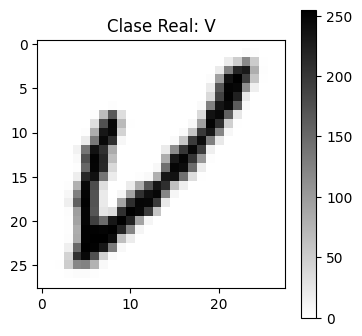

--> Datos normalizados exitosamente en el rango [0.0, 1.0]


In [2]:
# Inspección visual de una muestra al azar para verificar orientación
plt.figure(figsize=(4,4))
plt.imshow(train_images[0].squeeze(), cmap=plt.cm.binary)
plt.title(f"Clase Real: {class_names[train_labels[0]]}")
plt.colorbar()
plt.grid(False)
plt.show()

# --- OPERACIÓN DE NORMALIZACIÓN ESCALAR ---
# Transformamos los píxeles de enteros [0, 255] a flotantes continuos [0.0, 1.0]
train_images = train_images / 255.0
test_images = test_images / 255.0
print("--> Datos normalizados exitosamente en el rango [0.0, 1.0]")

In [3]:
# =====================================================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED (FLUJO DE TENSORES)
# =====================================================================
model_clasificador = keras.Sequential([
    # 1. Capa Flatten: Desenrola la matriz de 28x28x1 en un vector plano de 784 entradas
    keras.layers.Flatten(input_shape=(28, 28, 1)),

    # 2. Capa Oculta Densa 1: Extracción primaria de trazos estructurales
    keras.layers.Dense(units=256, activation='relu'),

    # 3. Capa Oculta Densa 2: Sub-abstracciones complejas
    keras.layers.Dense(units=128, activation='relu'),

    # 4. Capa de Salida Softmax: Distribución probabilística para las 47 clases independientes
    keras.layers.Dense(units=47, activation='softmax')
])

print("Resumen de la arquitectura alfanumérica diseñada:")
model_clasificador.summary()

Resumen de la arquitectura alfanumérica diseñada:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,919 (937.18 KB)

 Trainable params: 239,919 (937.18 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# =====================================================================
# ETAPA B y C: COMPILACIÓN Y ENTRENAMIENTO DINÁMICO
# =====================================================================
model_clasificador.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Iniciando el entrenamiento del clasificador alfanumérica (EMNIST)...")
# Entrenamos por 12 épocas con un batch de 64 para agilizar la ejecución en la nube
history_clasificador = model_clasificador.fit(
    train_images, train_labels,
    epochs=12,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)
print("\n¡Entrenamiento completado!")

Iniciando el entrenamiento del clasificador alfanumérica (EMNIST)...
Epoch 1/12
1587/1587 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.7075 - loss: 0.9942 - val_accuracy: 0.7951 - val_loss: 0.6575
Epoch 2/12
1587/1587 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8122 - loss: 0.5748 - val_accuracy: 0.8105 - val_loss: 0.5780
Epoch 3/12
1587/1587 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8353 - loss: 0.4862 - val_accuracy: 0.8363 - val_loss: 0.4975
Epoch 4/12
1587/1587 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8493 - loss: 0.4315 - val_accuracy: 0.8337 - val_loss: 0.4878
Epoch 5/12
1587/1587 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8600 - loss: 0.3918 - val_accuracy: 0.8318 - val_loss: 0.5019
Epoch 6/12
1587/1587 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8689 - loss: 0.3623 - val_accuracy: 0.8332 - val_loss: 0.4912
Epoch 7/12
1587/1587 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8749 - loss: 0.3382 - val_accuracy: 0.8456 - val_loss: 0.4714
Epoch 8/12
158

In [5]:
test_loss, test_acc = model_clasificador.evaluate(test_images, test_labels, verbose=2)
print(f"\n--> Precisión General de Testeo en EMNIST (Accuracy): {test_acc*100:.2f}%")

588/588 - 1s - 2ms/step - accuracy: 0.8344 - loss: 0.5753

--> Precisión General de Testeo en EMNIST (Accuracy): 83.44%


In [9]:
# Generación del vector de salida probabilístico para todas las muestras de prueba
predicciones_probabilisticas = model_clasificador.predict(test_images)

# Ejemplo de inspección de la primera muestra de prueba:
print("Estructura del vector Softmax para la muestra [0]:\n", predicciones_probabilisticas[0])
print(f"\n--> Índice con mayor probabilidad calculada: {np.argmax(predicciones_probabilisticas[0])} -> Caracter: {class_names[np.argmax(predicciones_probabilisticas[0])]}")
print(f"--> Etiqueta real registrada en el dataset:   {test_labels[0]} -> Caracter: {class_names[test_labels[0]]}")

print("\n====================================================================")
print("¡RETO ACTIVADO! Desarrolla tu lógica de filtrado y visualización abajo.")
print("====================================================================")

# TODO: Escribe aquí tu código para identificar y graficar 3 caracteres manuscritos fallidos.
# Pista: Encuentra índices donde np.argmax(predicciones_probabilisticas[i]) != test_labels[i]

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Estructura del vector Softmax para la muestra [0]:
 [1.02757110e-06 1.75806818e-08 9.10995528e-04 1.98844710e-08
 1.77422910e-10 3.99990402e-10 4.50688660e-08 1.54391572e-07
 5.97241183e-07 5.83008750e-06 2.88497995e-06 2.63924630e-06
 1.63810455e-06 7.77664511e-09 3.47303377e-08 7.68263952e-10
 5.17510625e-06 1.12826935e-11 2.43559484e-08 6.22518814e-10
 7.46545381e-10 1.87991134e-08 2.27901182e-06 5.11146197e-07
 8.39867596e-07 9.37897093e-10 2.13528350e-02 5.35153304e-05
 1.09753593e-07 1.22932964e-09 5.65515904e-07 3.21550772e-11
 9.47237844e-11 2.10589368e-09 9.97975747e-12 3.73573641e-07
 9.39294100e-01 1.51662471e-05 3.53801028e-07 2.37010372e-05
 1.84066238e-08 2.50381455e-02 1.39269951e-09 1.79219626e-06
 1.32786874e-02 5.86279930e-06 8.13932810e-11]

--> Índice con mayor probabilidad calculada: 36 -> Caracter: a
--> Etiqueta real registrada en el dataset:   36 -> Caracter: a

¡RETO ACTIVADO! Desarrolla tu lógica de filtrado y visualiza

In [11]:
# @title 🛠️ Laboratorio Interactivo: Prueba Caligráfica en Tiempo Real (Inferencia Libre)

import cv2
import numpy as np
import IPython
from base64 import b64decode
from google.colab import output

# =====================================================================
# INTERFAZ INTERACTIVA AVANZADA: CANVAS PARA MODELO DENSO (EMNIST)
# =====================================================================

html_interface_mlp = """
<div style="display: flex; flex-direction: column; align-items: center; justify-content: center; background-color: #0f172a; padding: 25px; border-radius: 12px; font-family: sans-serif; color: white; border: 1px solid #f97316; max-width: 650px; margin: 0 auto;">
    <h3 style="margin-bottom: 5px; color: #f97316; font-size: 20px;">🔬 Unidad de Telecomunicaciones ABAE - Sandbox Alfanumérico</h3>
    <p style="font-size: 13px; color: #94a3b8; margin-bottom: 20px; text-align: center;">Dibuja un dígito (0-9) o una letra (A-Z, a-z) dentro del recuadro negro para evaluar la red profunda.</p>

    <div style="display: flex; gap: 30px; margin-bottom: 20px; justify-content: center; align-items: center;">
        <div style="text-align: center;">
            <p style="margin-bottom: 8px; font-size: 14px; color: #94a3b8; font-weight: bold;">Trazo Manualizado:</p>
            <canvas id="canvas_mlp" width="280" height="280" style="border: 2px solid #f97316; background-color: black; cursor: crosshair; border-radius: 8px; box-shadow: 0 4px 6px -1px rgb(0 0 0 / 0.5);"></canvas>
        </div>

        <div style="text-align: center;">
            <p style="margin-bottom: 8px; font-size: 14px; color: #94a3b8; font-weight: bold;">Predicción Softmax (IA):</p>
            <div id="resultado_mlp" style="width: 280px; height: 280px; border: 2px dashed #38bdf8; background-color: #1e293b; display: flex; align-items: center; justify-content: center; font-size: 120px; font-weight: bold; color: #38bdf8; border-radius: 8px; box-shadow: 0 4px 6px -1px rgb(0 0 0 / 0.5);">?</div>
        </div>
    </div>

    <div style="display: flex; gap: 15px;">
        <button id="btn_borrar_mlp" style="background-color: #ef4444; color: white; border: none; padding: 12px 24px; font-size: 15px; border-radius: 6px; cursor: pointer; font-weight: bold; transition: 0.2s;">🧹 Limpiar Lienzo</button>
        <button id="btn_predecir_mlp" style="background-color: #f97316; color: white; border: none; padding: 12px 24px; font-size: 15px; border-radius: 6px; cursor: pointer; font-weight: bold; transition: 0.2s;">🧠 Evaluar Red Profunda</button>
    </div>
</div>

<script>
    const canvasMlp = document.getElementById('canvas_mlp');
    const ctxMlp = canvasMlp.getContext('2d');
    const resDivMlp = document.getElementById('resultado_mlp');
    let dibujandoMlp = false;

    // Configuración del trazo para emular el grosor del dataset EMNIST
    ctxMlp.strokeStyle = 'white';
    ctxMlp.lineWidth = 20;
    ctxMlp.lineCap = 'round';
    ctxMlp.lineJoin = 'round';

    canvasMlp.addEventListener('mousedown', (e) => { dibujandoMlp = true; ctxMlp.beginPath(); ctxMlp.moveTo(e.offsetX, e.offsetY); });
    canvasMlp.addEventListener('mousemove', (e) => { if (dibujandoMlp) { ctxMlp.lineTo(e.offsetX, e.offsetY); ctxMlp.stroke(); } });
    canvasMlp.addEventListener('mouseup', () => dibujandoMlp = false);
    canvasMlp.addEventListener('mouseleave', () => dibujandoMlp = false);

    document.getElementById('btn_borrar_mlp').addEventListener('click', () => {
        ctxMlp.clearRect(0, 0, canvasMlp.width, canvasMlp.height);
        resDivMlp.innerText = '?';
        resDivMlp.style.color = '#38bdf8';
    });

    document.getElementById('btn_predecir_mlp').addEventListener('click', async () => {
        resDivMlp.innerText = "⏳";
        resDivMlp.style.color = '#94a3b8';
        const dataURL = canvasMlp.toDataURL('image/png');
        const resultado = await google.colab.kernel.invokeFunction('notebook.predecir_trazo_mlp', [dataURL], {});
        resDivMlp.innerText = resultado.data['text/plain'].replace(/'/g, "");
        resDivMlp.style.color = '#38bdf8';
    });
</script>
"""

def procesar_y_predecir_mlp(data_url):
    # Decodificar el string base64 enviado por el lienzo de HTML5
    header, encoded = data_url.split(',', 1)
    data = b64decode(encoded)
    nparr = np.frombuffer(data, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)

    # Aislar el canal Alpha (transparencia del trazo blanco sobre fondo transparente)
    if img.shape[2] == 4:
        img_gray = img[:, :, 3]
    else:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Redimensionar a la escala estándar requerida por la arquitectura (28x28 píxeles)
    img_resized = cv2.resize(img_gray, (28, 28), interpolation=cv2.INTER_AREA)

    # Normalización escalar idéntica al conjunto de entrenamiento
    img_normalized = img_resized.astype('float32') / 255.0

    # Adaptación dimensional crucial para redes Densas: (Lote=1, Ancho=28, Alto=28, Canales=1)
    # Añadir la dimensión del canal y luego la dimensión del lote para que coincida con la entrada del modelo
    input_tensor = np.expand_dims(img_normalized, axis=-1) # (28, 28) -> (28, 28, 1)
    input_tensor = np.expand_dims(input_tensor, axis=0)  # (28, 28, 1) -> (1, 28, 28, 1)

    # Inferencia probabilística con el clasificador multiclase
    predicciones = model_clasificador.predict(input_tensor, verbose=0)
    clase_predicha = np.argmax(predicciones)

    # Diccionario analítico oficial de 47 categorías indexadas en EMNIST Balanced
    class_names_emnist = [
        '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
        'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
        'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
    ]

    if 0 <= clase_predicha < len(class_names_emnist):
        return class_names_emnist[clase_predicha]
    else:
        return "?"

# Registrar la rutina en el backend del kernel de Google Colab
output.register_callback('notebook.predecir_trazo_mlp', procesar_y_predecir_mlp)

# Renderizar la interfaz visual en la celda de salida
IPython.display.display(IPython.display.HTML(html_interface_mlp))

In [12]:
# =====================================================================
# AJUSTE DIMENSIONAL OBLIGATORIO PARA ARQUITECTURAS CONVOLUCIONALES
# =====================================================================

# Añadimos el canal de color (28, 28) -> (28, 28, 1)
train_images_cnn = train_images.reshape(-1, 28, 28, 1)
test_images_cnn = test_images.reshape(-1, 28, 28, 1)

print(f"Nueva forma del set de entrenamiento para CNN: {train_images_cnn.shape}")
print(f"Nueva forma del set de prueba para CNN:        {test_images_cnn.shape}")

Nueva forma del set de entrenamiento para CNN: (112800, 28, 28, 1)
Nueva forma del set de prueba para CNN:        (18800, 28, 28, 1)


In [13]:
# =====================================================================
# ETAPA A: ARQUITECTURA DE LA RED NEURONAL CONVOLUCIONAL (CNN)
# =====================================================================

model_cnn = keras.Sequential([
    # Bloque Extractor 1: Detecta rasgos geométricos simples (bordes, líneas)
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloque Extractor 2: Detecta combinaciones complejas (curvas, uniones de trazos)
    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloque Clasificador: Aplana los mapas de características y toma la decisión
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.2), # Previene el sobreajuste (overfitting)

    # Capa de salida para las 47 clases de EMNIST Balanced
    keras.layers.Dense(units=47, activation='softmax')
])

print("Resumen de la arquitectura Convolucional (CNN):")
model_cnn.summary()

Resumen de la arquitectura Convolucional (CNN):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# =====================================================================
# ETAPAS B y C: COMPILACIÓN Y ENTRENAMIENTO DE LA CNN
# =====================================================================

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Iniciando el entrenamiento de la red convolucional (CNN)...")
# Usamos un batch de 128 para acelerar el procesamiento en Colab
history_cnn = model_cnn.fit(
    train_images_cnn, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\n¡Entrenamiento de la CNN finalizado con éxito!")

# Validación frente al set de testeo
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(test_images_cnn, test_labels, verbose=0)
print(f"--> Precisión de la CNN en el set de prueba: {test_acc_cnn*100:.2f}%")

Iniciando el entrenamiento de la red convolucional (CNN)...
Epoch 1/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - accuracy: 0.6874 - loss: 1.0419 - val_accuracy: 0.8293 - val_loss: 0.5102
Epoch 2/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 79s 94ms/step - accuracy: 0.8182 - loss: 0.5485 - val_accuracy: 0.8492 - val_loss: 0.4349
Epoch 3/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.8405 - loss: 0.4690 - val_accuracy: 0.8590 - val_loss: 0.4033
Epoch 4/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.8533 - loss: 0.4220 - val_accuracy: 0.8671 - val_loss: 0.3760
Epoch 5/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 80s 92ms/step - accuracy: 0.8630 - loss: 0.3930 - val_accuracy: 0.8730 - val_loss: 0.3593
Epoch 6/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 74s 93ms/step - accuracy: 0.8688 - loss: 0.3702 - val_accuracy: 0.8754 - val_loss: 0.3471
Epoch 7/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.8752 - loss: 0.3473 - val_accuracy: 0.8766 - val_loss: 0.3494
Epoch 8/10
794/794 ━━━━━━━━━━━

In [15]:
# @title 🛠️ Laboratorio Interactivo: Evaluación del Trazo Libre con CNN

import cv2
import numpy as np
import IPython
from base64 import b64decode
from google.colab import output

# =====================================================================
# INTERFAZ INTERACTIVA AVANZADA: CANVAS PARA MODELO CONVOLUCIONAL
# =====================================================================

html_interface_cnn = """
<div style="display: flex; flex-direction: column; align-items: center; justify-content: center; background-color: #0f172a; padding: 25px; border-radius: 12px; font-family: sans-serif; color: white; border: 1px solid #10b981; max-width: 650px; margin: 0 auto;">
    <h3 style="margin-bottom: 5px; color: #10b981; font-size: 20px;">🔬 Unidad de Telecomunicaciones ABAE - Sandbox Convolucional</h3>
    <p style="font-size: 13px; color: #94a3b8; margin-bottom: 20px; text-align: center;">Dibuja cualquier carácter alfanumérico (0-9, A-Z, a-z) de EMNIST en el lienzo negro.</p>

    <div style="display: flex; gap: 30px; margin-bottom: 20px; justify-content: center; align-items: center;">
        <div style="text-align: center;">
            <p style="margin-bottom: 8px; font-size: 14px; color: #94a3b8; font-weight: bold;">Trazo Libre Manual:</p>
            <canvas id="canvas_cnn" width="280" height="280" style="border: 2px solid #10b981; background-color: black; cursor: crosshair; border-radius: 8px; box-shadow: 0 4px 6px -1px rgb(0 0 0 / 0.5);"></canvas>
        </div>

        <div style="text-align: center;">
            <p style="margin-bottom: 8px; font-size: 14px; color: #94a3b8; font-weight: bold;">Predicción de la CNN:</p>
            <div id="resultado_cnn" style="width: 280px; height: 280px; border: 2px dashed #38bdf8; background-color: #1e293b; display: flex; align-items: center; justify-content: center; font-size: 120px; font-weight: bold; color: #38bdf8; border-radius: 8px; box-shadow: 0 4px 6px -1px rgb(0 0 0 / 0.5);">?</div>
        </div>
    </div>

    <div style="display: flex; gap: 15px;">
        <button id="btn_borrar_cnn" style="background-color: #ef4444; color: white; border: none; padding: 12px 24px; font-size: 15px; border-radius: 6px; cursor: pointer; font-weight: bold; transition: 0.2s;">🧹 Limpiar Lienzo</button>
        <button id="btn_predecir_cnn" style="background-color: #10b981; color: white; border: none; padding: 12px 24px; font-size: 15px; border-radius: 6px; cursor: pointer; font-weight: bold; transition: 0.2s;">🧠 Evaluar con CNN</button>
    </div>
</div>

<script>
    const canvasCnn = document.getElementById('canvas_cnn');
    const ctxCnn = canvasCnn.getContext('2d');
    const resDivCnn = document.getElementById('resultado_cnn');
    let dibujandoCnn = false;

    // Configuración del trazo grueso para emular la densidad de EMNIST
    ctxCnn.strokeStyle = 'white';
    ctxCnn.lineWidth = 22;
    ctxCnn.lineCap = 'round';
    ctxCnn.lineJoin = 'round';

    canvasCnn.addEventListener('mousedown', (e) => { dibujandoCnn = true; ctxCnn.beginPath(); ctxCnn.moveTo(e.offsetX, e.offsetY); });
    canvasCnn.addEventListener('mousemove', (e) => { if (dibujandoCnn) { ctxCnn.lineTo(e.offsetX, e.offsetY); ctxCnn.stroke(); } });
    canvasCnn.addEventListener('mouseup', () => dibujandoCnn = false);
    canvasCnn.addEventListener('mouseleave', () => dibujandoCnn = false);

    document.getElementById('btn_borrar_cnn').addEventListener('click', () => {
        ctxCnn.clearRect(0, 0, canvasCnn.width, canvasCnn.height);
        resDivCnn.innerText = '?';
        resDivCnn.style.color = '#38bdf8';
    });

    document.getElementById('btn_predecir_cnn').addEventListener('click', async () => {
        resDivCnn.innerText = "⏳";
        resDivCnn.style.color = '#94a3b8';
        const dataURL = canvasCnn.toDataURL('image/png');
        const resultado = await google.colab.kernel.invokeFunction('notebook.predecir_trazo_cnn', [dataURL], {});
        resDivCnn.innerText = resultado.data['text/plain'].replace(/'/g, "");
        resDivCnn.style.color = '#38bdf8';
    });
</script>
"""

def procesar_y_predecir_cnn(data_url):
    # Decodificar el string base64 del canvas
    header, encoded = data_url.split(',', 1)
    data = b64decode(encoded)
    nparr = np.frombuffer(data, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)

    # Aislar el canal Alpha (trazo blanco)
    if img.shape[2] == 4:
        img_gray = img[:, :, 3]
    else:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- ALGORITMO DE ROBUSTECIMIENTO: ENCUADRE Y CENTRADO DE CONTORNO ---
    borde_pixeles = cv2.findNonZero(img_gray)
    if borde_pixeles is not None:
        x, y, w, h = cv2.boundingRect(borde_pixeles)
        img_recortada = img_gray[y:y+h, x:x+w]

        # Insertamos un margen de protección (padding del 18%) para centrar el carácter
        margen = int(max(w, h) * 0.18)
        img_padded = cv2.copyMakeBorder(img_recortada, margen, margen, margen, margen,
                                         cv2.BORDER_CONSTANT, value=0)
    else:
        img_padded = img_gray

    # Redimensionar al tamaño reglamentario de 28x28 píxeles
    img_resized = cv2.resize(img_padded, (28, 28), interpolation=cv2.INTER_AREA)
    img_normalized = img_resized.astype('float32') / 255.0

    # Tensor de 4 dimensiones estrictamente exigido por la CNN: (Lote=1, Ancho=28, Alto=28, Canales=1)
    input_tensor = np.expand_dims(np.expand_dims(img_normalized, axis=-1), axis=0)

    # Inferencia probabilística con el nuevo modelo CNN
    predicciones = model_cnn.predict(input_tensor, verbose=0)
    clase_predicha = np.argmax(predicciones)

    # Diccionario analítico de las 47 clases de EMNIST Balanced
    class_names_emnist = [
        '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
        'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
        'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
    ]

    if 0 <= clase_predicha < len(class_names_emnist):
        return class_names_emnist[clase_predicha]
    else:
        return "?"

# Registrar la nueva llamada de retorno vinculada al backend de la CNN
output.register_callback('notebook.predecir_trazo_cnn', procesar_y_predecir_cnn)

# Desplegar la interfaz gráfica final en la celda
IPython.display.display(IPython.display.HTML(html_interface_cnn))